# Downloading the Devon Ice Cap airborne gravity survey

Accessed from https://dataverse.tdl.org/dataset.xhtml?persistentId=doi:10.18738/T8/OQWRKP

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import verde as vd

import airbornegeo

## load data

Manually download the entire ZIP files from: https://dataverse.tdl.org/dataset.xhtml?persistentId=doi:10.18738/T8/OQWRKP

Unzip it and place it in `docs/data`.

In [5]:
from pathlib import Path

path = Path("../data/doi-10.18738-t8-oqwrkp/2019_DIC_UTIG.IGCMG2").glob("*")
pathfiles = [x for x in path if x.is_file()]
pathfiles

[PosixPath('../data/doi-10.18738-t8-oqwrkp/2019_DIC_UTIG.IGCMG2/IGCMG2_2018151_DEV_JKB2t_Y83b.txt'),
 PosixPath('../data/doi-10.18738-t8-oqwrkp/2019_DIC_UTIG.IGCMG2/IGCMG2_2018158_DEV_JKB2t_Y57a.txt'),
 PosixPath('../data/doi-10.18738-t8-oqwrkp/2019_DIC_UTIG.IGCMG2/IGCMG2_2018151_DEV_JKB2t_Y51a.txt'),
 PosixPath('../data/doi-10.18738-t8-oqwrkp/2019_DIC_UTIG.IGCMG2/IGCMG2_2018155_DEV_JKB2t_X81a.txt'),
 PosixPath('../data/doi-10.18738-t8-oqwrkp/2019_DIC_UTIG.IGCMG2/IGCMG2_2018158_DEV_JKB2t_Y89a.txt'),
 PosixPath('../data/doi-10.18738-t8-oqwrkp/2019_DIC_UTIG.IGCMG2/IGCMG2_2018157_DEV_JKB2t_Y77a.txt'),
 PosixPath('../data/doi-10.18738-t8-oqwrkp/2019_DIC_UTIG.IGCMG2/IGCMG2_2018155_DEV_JKB2t_X77a.txt'),
 PosixPath('../data/doi-10.18738-t8-oqwrkp/2019_DIC_UTIG.IGCMG2/IGCMG2_2018155_DEV_JKB2t_Y47b.txt'),
 PosixPath('../data/doi-10.18738-t8-oqwrkp/2019_DIC_UTIG.IGCMG2/IGCMG2_2018157_DEV_JKB2t_Y53a.txt'),
 PosixPath('../data/doi-10.18738-t8-oqwrkp/2019_DIC_UTIG.IGCMG2/IGCMG2_2018153_DEV_JKB2t_Y5

In [6]:
dfs = []
flights = []
for p in pathfiles:
    df = pd.read_csv(
        p,
        skiprows=58,
        sep=r"\s+",
        header=None,
        names=[
            "year",
            "day_of_year",
            "seconds_of_day",
            "lon",  # wgs 84
            "lat",  # wgs 84
            "gravity_disturbance",  # filtered (2sec box car) mag anom with IGRF13 removed
            "height",  # aircraft elevation WGS84
        ],
    )
    # get flight ID from end of file name
    flight = str(p).split("_")[-1][:-4]
    if flight in flights:
        print(f"Flight {flight} is in multiple files")
    flights.append(flight)
    df["flight_id"] = flight

    dfs.append(df)
data_df = pd.concat(dfs)
data_df

Flight Y81a is in multiple files
Flight Y83a is in multiple files


,year,day_of_year,seconds_of_day,lon,lat,gravity_disturbance,height,flight_id
0,2018,151,28063.4261,-83.757332,75.521317,NaN,NaN,Y83b
1,2018,151,28064.4208,-83.760437,75.521423,NaN,NaN,Y83b
2,2018,151,28065.4189,-83.763527,75.521553,NaN,NaN,Y83b
3,2018,151,28066.4208,-83.766617,75.521683,NaN,NaN,Y83b
4,2018,151,28067.4230,-83.769676,75.521828,NaN,NaN,Y83b
...,...,...,...,...,...,...,...,...
293,2018,158,15976.3137,-83.051353,75.272881,134.723,2159.051,Y83a
294,2018,158,15977.3156,-83.054047,75.272423,134.727,2158.982,Y83a
295,2018,158,15978.3155,-83.056763,75.271950,NaN,NaN,Y83a
296,2018,158,15979.3158,-83.059464,75.271477,NaN,NaN,Y83a


In [7]:
data_df.flight_id.unique()

<ArrowStringArray>
[    'Y83b',     'Y57a',     'Y51a',     'X81a',     'Y89a',     'Y77a',
     'X77a',     'Y47b',     'Y53a',     'Y55a',     'X47a',     'X72a',
     'X63a',     'X83a',     'X55a',     'X37a',     'Y73a',     'X73a',
     'Y71a',     'X87a',     'Y59a',     'Y91a',     'Y83a',     'X67a',
     'Y69a',     'Y81a',     'Y63a',     'X80a',     'Y82a',     'X59a',
     'Y90a',     'X69a',     'X79a',     'X71a',     'X86a',     'X57a',
     'Y85a',     'X97a',     'Y75a',     'X95a',     'Y47a',     'X33a',
    'X101a',     'X76a',     'X61a',     'X75a',     'X78a',     'Y87a',
     'X93a',     'X85a',     'Y65a',      'Y5a',     'X41a',     'Y67a',
     'X84a',     'X99a',    'X103a',     'X91a',     'X65a',     'X89a',
     'Y49a',     'X29a',     'Y87b',     'X51a', 'IB95530a',     'Y79a',
     'X45a',     'Y61a',     'X82a',     'X53a',     'X49a',     'X74a']
Length: 72, dtype: str

In [ ]:
# make unique flight number as float for plotting
data_df["flight"] = airbornegeo.unique_line_id(data_df, line_col_name="flight_id")
data_df.flight.unique()

## Reproject

In [9]:
data_df["easting"], data_df["northing"] = airbornegeo.reproject(
    data_df.lon,
    data_df.lat,
    input_crs="EPSG:4326",
    output_crs="EPSG:3413",
)
data_df.head()

,year,day_of_year,seconds_of_day,lon,lat,gravity_disturbance,height,flight_id,flight,easting,northing
0,2018,151,28063.4261,-83.757332,75.521317,NaN,NaN,Y83b,1,-986925.413036,-1.229361e+06
1,2018,151,28064.4208,-83.760437,75.521423,NaN,NaN,Y83b,1,-986984.733434,-1.229299e+06
2,2018,151,28065.4189,-83.763527,75.521553,NaN,NaN,Y83b,1,-987042.075133,-1.229234e+06
3,2018,151,28066.4208,-83.766617,75.521683,NaN,NaN,Y83b,1,-987099.412760,-1.229170e+06
4,2018,151,28067.4230,-83.769676,75.521828,NaN,NaN,Y83b,1,-987155.048041,-1.229105e+06


## Plot data

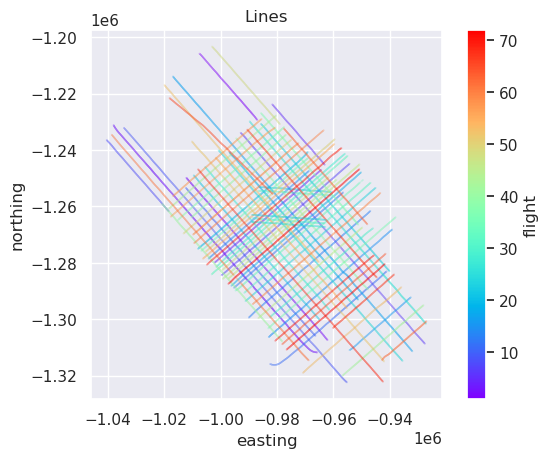

In [10]:
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="flight",
    s=0.002,
    cmap="rainbow",
    title="Lines",
)
ax.set_aspect("equal")

In [11]:
data_df.head()

,year,day_of_year,seconds_of_day,lon,lat,gravity_disturbance,height,flight_id,flight,easting,northing
0,2018,151,28063.4261,-83.757332,75.521317,NaN,NaN,Y83b,1,-986925.413036,-1.229361e+06
1,2018,151,28064.4208,-83.760437,75.521423,NaN,NaN,Y83b,1,-986984.733434,-1.229299e+06
2,2018,151,28065.4189,-83.763527,75.521553,NaN,NaN,Y83b,1,-987042.075133,-1.229234e+06
3,2018,151,28066.4208,-83.766617,75.521683,NaN,NaN,Y83b,1,-987099.412760,-1.229170e+06
4,2018,151,28067.4230,-83.769676,75.521828,NaN,NaN,Y83b,1,-987155.048041,-1.229105e+06


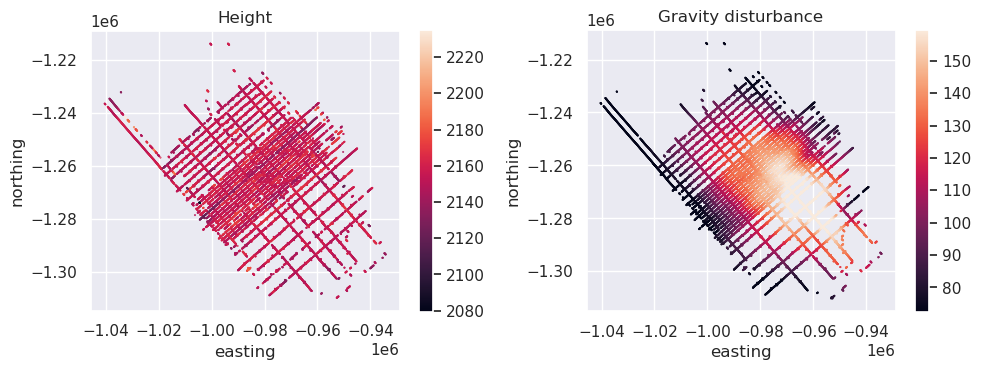

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

df = data_df

ax = df.plot.scatter(
    "easting",
    "northing",
    c="height",
    s=0.2,
    ax=axs[0],
    colorbar=False,
    title="Height",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

cpt_lims = vd.minmax(data_df.gravity_disturbance, min_percentile=5, max_percentile=95)
ax = df.plot.scatter(
    "easting",
    "northing",
    c="gravity_disturbance",
    s=0.2,
    ax=axs[1],
    colorbar=False,
    vmin=cpt_lims[0],
    vmax=cpt_lims[1],
    title="Gravity disturbance",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()